**IMPORTING NECCESSARY LIBRARIES**

In [33]:

# Step 1: Import Required Libraries
import pandas as pd
import re
from bs4 import BeautifulSoup
import warnings
from bs4 import MarkupResemblesLocatorWarning
import nltk
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Suppress BeautifulSoup warning about file-like input
warnings.filterwarnings("ignore", category=MarkupResemblesLocatorWarning)

In [34]:
# Download NLTK resources
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

**INITIALIZE STEMMER AND LEMMATIZER**

In [36]:
# Initialize stemmer and lemmatizer
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
lemmatizer

<WordNetLemmatizer>

**LOADING THE DATASET**

In [37]:

# Load the dataset
raw_df = pd.read_csv("/content/HateSpeechRaw.csv")

# List all column names to identify the tweet column
raw_df.columns


Index(['tweet'], dtype='object')

**SPLITTING AND EXTRACTING THE TWEET COLUMN**

In [39]:
# Split and extract the tweet text column
df_split = raw_df['tweet'].str.split(';', expand=True)
df = df_split[[4]].copy()
df.columns = ['text']
df.drop_duplicates(inplace=True)  # Remove duplicate entries
df_split

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
0,,2017-10-18 11:04,0,0,"""That #ShangweVedio should be replaced. Where ...",,,#ShangweVedio #AkombeMustGo,"""920561132846374912""",https://twitter.com/GordonOka/status/920561132...,...,None,None,None,None,None,None,None,None,None,None
1,,2017-10-18 09:15,0,1,"""they wrote letters to iebc their bloggers tre...",,,#akombemustgo,"""920533868758872064""",https://twitter.com/Kianangih/status/920533868...,...,None,None,None,None,None,None,None,None,None,None
2,,2017-10-18 09:06,0,2,"""Akombe was a nasa mole Jubilee never wanted...",,,#AkombeMustGo,"""920531601775316992""",https://twitter.com/Kianangih/status/920531601...,...,None,None,None,None,None,None,None,None,None,None
3,,2017-10-04 12:24,0,0,"""@paulinenjoroge @OleItumbi @JubileePartyK @Te...",,@paulinenjoroge @OleItumbi @JubileePartyK @Tea...,#AkombeMustGo,"""915507834841976832""",https://twitter.com/PapaJesse4/status/91550783...,...,None,None,None,None,None,None,None,None,None,None
4,,2017-09-25 20:20,0,0,"""#akombemustgo""",,,#akombemustgo,"""912366240160677889""",https://twitter.com/dennisomanga/status/912366...,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155231,,2017-08-08 10:50,2,7,"""Haha this hashtag is tribal. Out of 44 kenyan...",,,#NASAExposed,"""894828026411851776""",https://twitter.com/otangah/status/89482802641...,...,None,None,None,None,None,None,None,None,None,None
155232,,2017-08-08 10:36,0,1,"""Kikuyus dont even love this man are you ready...",,,,"""894824565116948480""",https://twitter.com/breebreveta35/status/89482...,...,None,None,None,None,None,None,None,None,None,None
155233,,2017-08-08 08:59,3,2,"""Me I have lived with Kikuyus all my life and ...",,,,"""894800234034982912""",https://twitter.com/gufydox/status/89480023403...,...,None,None,None,None,None,None,None,None,None,None
155234,,2017-08-08 06:25,0,1,"""When other tribes are saying that we will hav...",,,,"""894761553479610373""",https://twitter.com/KelvinJomo/status/89476155...,...,None,None,None,None,None,None,None,None,None,None


This function:

Strips away HTML tags using BeautifulSoup.

Normalizes whitespace using regex (e.g., multiple spaces/tabs → single space).

Returns clean, plain text.


REMOVING HTML TAGS AND SPECIAL CHARACTERS

HANDLING WHITESPACE AND EXTRA SPACES

In [40]:
# cleaning html white spaces
import re
from bs4 import BeautifulSoup
import pandas as pd

def clean_html_whitespace(text):
    if pd.isnull(text):
        return ""

    text = BeautifulSoup(text, "html.parser").get_text()
    text = re.sub(r'\s+', ' ', text).strip()
    return text

**STOPWORD REMOVAL**


In [41]:
# Step 3: Define Stopwords
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
stop_words

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

**TOKENIZATION,NORMALIZATION(LOWERCASTING,STEMMING,LEMMATIZATION)**

In [42]:
contractions_dict = {
    "can't": "cannot", "won't": "will not", "n't": " not", "'re": " are",
    "'s": " is", "'d": " would", "'ll": " will", "'t": " not",
    "'ve": " have", "'m": " am"
}
contractions_re = re.compile('(%s)' % '|'.join(map(re.escape, contractions_dict.keys())))

def expand_contractions(text):
    return contractions_re.sub(lambda match: contractions_dict[match.group(0)], text)

# Step 2: Preprocessing Function (Fast Version)
def preprocess_text_fast(text):
    if pd.isnull(text):
        return ""

    text = BeautifulSoup(text, "html.parser").get_text()
    text = expand_contractions(text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words] #tokenization
    tokens = [stemmer.stem(word) for word in tokens] #stemmartization
    tokens = [lemmatizer.lemmatize(word) for word in tokens] #lemmatization

    return ' '.join(tokens)


In [43]:
# Step 5: Apply Preprocessing to Dataset
# Display the result of preprocessing for the first 10 entry before applying it to all
print("Example Preprocessing Output (First 10 Rows):")
for i, sample_text in enumerate(df['text'].iloc[:10]):
    print(f"\nEntry {i+1}")
    print("Original: ", sample_text)
    print("Processed:", preprocess_text_fast(sample_text))

Example Preprocessing Output (First 10 Rows):

Entry 1
Original:  "That #ShangweVedio should be replaced. Where did #AkombeMustGo disappeared?"
Processed: shangwevedio replac akombemustgo disappear

Entry 2
Original:  "they wrote letters to iebc their bloggers trended #akombemustgo  ama you wanted them to call for riots?"
Processed: wrote letter iebc blogger trend akombemustgo ama want call riot

Entry 3
Original:  "Akombe was a nasa mole   Jubilee never wanted him  september 8 the 36 bloggers trended #AkombeMustGo  leaking "her chats" with orengo"
Processed: akomb nasa mole jubile never want septemb blogger trend akombemustgo leak chat orengo

Entry 4
Original:  "@paulinenjoroge @OleItumbi @JubileePartyK @TeamUhuru . @HonAdenDuale @KimaniIchungwa @HonMoses_Kuria Akuna kulala 24/7 #AkombeMustGo pic.twitter.com/6wFYu4RYwX"
Processed: paulinenjorog oleitumbi jubileepartyk teamuhuru honadendual kimaniichungwa honmoseskuria akuna kulala akombemustgo pictwittercomwfyurywx

Entry 5
Original:

**NOTES ON TOKENIZATION AND NORMALIZATION**

Due to the extensive size of the dataset and the significant processing time required, I applied tokenization and normalization steps but limited the output to only the first 10 rows for demonstration purposes. This was done to ensure efficiency during preliminary testing and avoid prolonged execution times.

In [44]:
from multiprocessing import Pool, cpu_count

def preprocess_all_texts(texts):
    with Pool(cpu_count()) as pool:
        return pool.map(preprocess_text_fast, texts)

df['clean_text'] = preprocess_all_texts(df['text'].tolist())

**EXPLORATORY DATA ANALYSIS(EDA)**

Top 10 most common words: [('kikuyu', 36309), ('http', 19029), ('luo', 12041), ('hate', 10774), ('electionsboycottk', 10471), ('kalenjin', 9247), ('chase', 9202), ('u', 9196), ('hawa', 8519), ('hatespeech', 8108)]


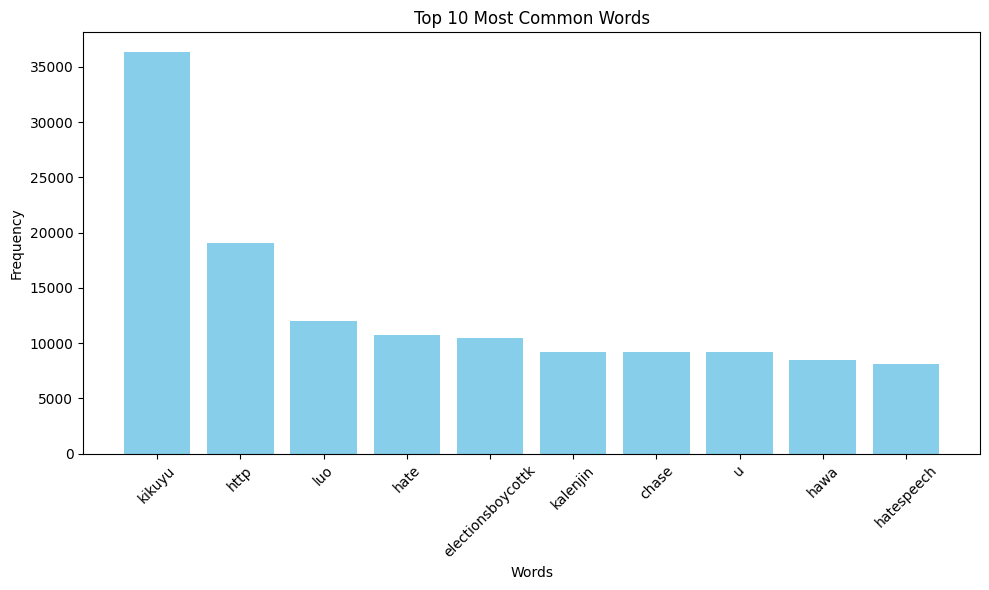

In [45]:
# Step 6: Exploratory Data Analysis (EDA)
from collections import Counter

# Word frequency using the cleaned sample
from collections import Counter

all_words = ' '.join(df['clean_text']).split()
word_freq = Counter(all_words)

print("Top 10 most common words:", word_freq.most_common(10))


import matplotlib.pyplot as plt

# Extract words and their frequencies
top_words = word_freq.most_common(10)
words = [word for word, freq in top_words]
frequencies = [freq for word, freq in top_words]

# Plot
plt.figure(figsize=(10, 6))
plt.bar(words, frequencies, color='skyblue')
plt.title("Top 10 Most Common Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**INTERPRETATION OF THE GRAPH**

**Overview of the Graph**
X-axis (Words): Shows the 10 most frequent words that appeared in your dataset.

Y-axis (Frequency): Indicates how many times each word appeared.

Bar height: Represents how often a word appears , the taller the bar, the more frequent the word.

**Interpretation of Key Data Points**

"kikuyu"

Appears the most frequently (around 36,000 times).

This could suggest that the Kikuyu ethnic group is a central topic in the dataset.

Context matters: It might reflect news, public discussions, or hate speech targeting this group.

"http"

Second most frequent.

Likely represents links shared in the dataset, probably from URLs in social media or scraped web content.

Indicates a lot of online content or references were captured.

"luo"

Another Kenyan ethnic group mentioned frequently (around 12,000 times).

Similar to "kikuyu", its high frequency could point to discussions involving ethnic identity or conflict.

"hate" and "hatespeech"

Indicates that the dataset likely involves sensitive or aggressive language, possibly collected to study hate speech.

These keywords show that the theme of hostility or discrimination is prominent.

"electionsboycott"

Suggests political discourse or activism.

Could indicate calls for boycotts during elections—important context for understanding political unrest or protest.

"kalenjin"

Yet another Kenyan ethnic group.

Its presence reinforces the notion that ethnicity is a key theme in this dataset.

"chase"

Might refer to actions like "chasing someone away" or metaphorical "political/economic chase."

Needs further context from the surrounding text to interpret precisely.

"u"

Possibly shorthand for "you" (common in social media or SMS text).

Shows informal or conversational data.

"hawa"

Swahili for "they" or "these people."

Might point to generalization or labeling of groups in discourse.

**Conclusions**

The data may have been sourced from social media, online forums, or public comments—given the presence of "http", informal language ("u"), and sociopolitical terms.

Ethnicity and hate speech are likely central themes.

The dataset might have been collected to analyze online hate speech, ethnic bias, or political sentiment in Kenya.

The use of both English and Swahili terms reflects the bilingual nature of discourse in Kenya.



Top 10 bigrams: [(('hawa', 'wazungu'), 2690), (('kikuyu', 'kalenjin'), 2426), (('hate', 'speech'), 1389), (('hate', 'kikuyu'), 1221), (('kenyapol', 'electionsboycottk'), 1112), (('hate', 'luo'), 983), (('electionsboycottk', 'kenyapol'), 900), (('kikuyu', 'luo'), 825), (('electionsboycottk', 'electionsboycottk'), 819), (('fagiawot', 'http'), 731)]
Top 10 bigrams: [(('hawa', 'wazungu'), 2690), (('kikuyu', 'kalenjin'), 2426), (('hate', 'speech'), 1389), (('hate', 'kikuyu'), 1221), (('kenyapol', 'electionsboycottk'), 1112), (('hate', 'luo'), 983), (('electionsboycottk', 'kenyapol'), 900), (('kikuyu', 'luo'), 825), (('electionsboycottk', 'electionsboycottk'), 819), (('fagiawot', 'http'), 731)]


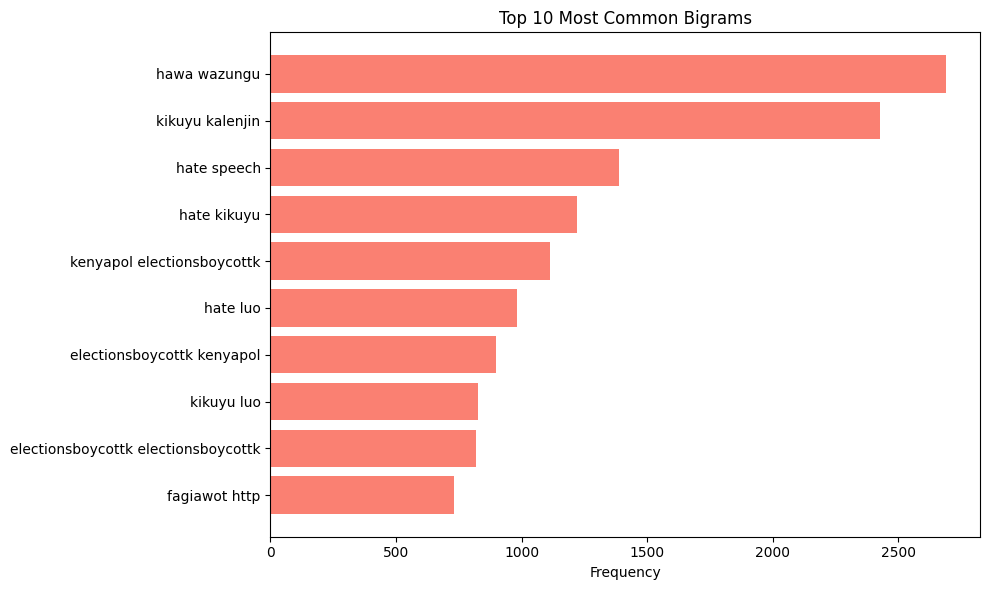

In [46]:
# Bigram frequency
from nltk import ngrams
all_bigrams = list(ngrams(all_words, 2))
bigram_freq = Counter(all_bigrams)
print("Top 10 bigrams:", bigram_freq.most_common(10))

# Bigram frequency
from nltk import ngrams
all_bigrams = list(ngrams(all_words, 2))
bigram_freq = Counter(all_bigrams)
print("Top 10 bigrams:", bigram_freq.most_common(10))

# Visualize Top 10 Bigrams
top_bigrams = bigram_freq.most_common(10)
bigrams = [' '.join(bigram) for bigram, freq in top_bigrams]
frequencies = [freq for bigram, freq in top_bigrams]

plt.figure(figsize=(10, 6))
plt.barh(bigrams, frequencies, color='salmon')
plt.xlabel("Frequency")
plt.title("Top 10 Most Common Bigrams")
plt.gca().invert_yaxis()  # highest at the top
plt.tight_layout()
plt.show()


**INTERPRETATION OF THE BIGRAM FREQUENCY**

This bar chart highlights the top 10 most frequent two-word combinations (bigrams) in the dataset. These combinations give a clearer sense of how words are being used together and can reveal themes, sentiments, or repeated phrases in conversations or texts.



**Detailed Breakdown of the Top Bigrams **


**"hawa wazungu"**

This Swahili phrase translates to “these white people.”
Its high frequency suggests a recurring conversation or criticism directed toward foreigners or white individuals, possibly in a political, historical, or racial context.

**"kikuyu kalenjin"**

These are two major ethnic groups in Kenya.
The frequent pairing could indicate discussions or tensions between these groups—likely in a political or electoral setting.

**"hate speech"**

This shows up prominently, pointing to the central theme of the dataset—possibly focused on detecting or analyzing hateful language.

**"hate kikuyu"**


This combination is concerning, as it directly indicates hate directed toward a specific ethnic group.
It may be used in hate speech analysis to highlight targeted group hostility.


**"kenyapol electionsboycottk"**


Appears to be a hashtag or a combination of keywords: Kenya Politics and Election Boycott.
Suggests that the content is politically charged, with conversations about refusing to participate in elections.


**"hate luo"**

Similar to “hate kikuyu,” this reveals hate directed at another ethnic group.
Again, reinforces the theme of ethnically motivated speech.


**"electionsboycottk kenyapol"**


Another variation of the elections and politics bigram.
Likely part of a campaign or repeated slogan.


"kikuyu luo"

Another ethnic pair that appears frequently.
Suggests comparative discussions or possibly conflict narratives.


"electionsboycottk electionsboycottk"
This repetition looks like a duplicated hashtag or chant, possibly from campaign posts or automated tweets.


**"fagiawot http"**

“Fagia wote” loosely translates from Swahili to “sweep them all”  often used in political slogans to call for removal of all corrupt leaders.
Paired with “http,” this likely appeared alongside shared links or campaign media online.


There is a strong presence of ethnically and politically sensitive language.
Bigram combinations indicate hate speech, ethnic polarization, and election-related activism (e.g., boycotts or reforms).
Online platforms (as hinted by the appearance of "http") were likely the source, possibly Twitter or other social media.

**Conclusion**

This graph doesn’t just show frequent word combinations,it tells a deeper story about what people are discussing, debating, or even fighting over. It captures a moment where ethnic identity, politics, and online discourse intersect, raising both societal concerns and opportunities for deeper analysis on how digital platforms reflect (or even amplify) real-world tensions.



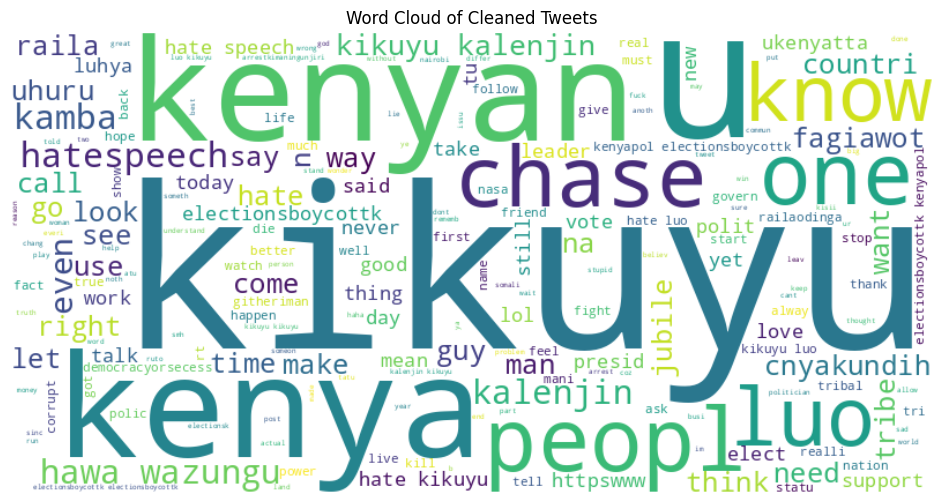

In [48]:
# Step 7: Optional Word Cloud Visualization
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(df['clean_text']))
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Cleaned Tweets")
plt.show()


**INTERPRETATION OF THE WORD CLOUD VISUALIZATION**


A word cloud is a visual representation of word frequency in text data:
Larger words appear more often in the tweets.
Smaller words are less frequent.
Words are usually cleaned (lowercased, stripped of punctuation, and often stopwords removed).

**Key Observations from the Word Cloud**

**Most Prominent Words (Highly Frequent)**
"kenya", "kenyan", "kikuyu", "luo", "uchase", "people", "one", "know"
These are the most visible and frequent terms.
Their size shows they are central to the conversations happening in the dataset.

**Ethnic Group Mentions**

"kikuyu", "luo", "kalenjin", "kamba", "luhya"
This reveals that ethnicity is a dominant theme in the tweets.
Likely points to discussions around ethnic politics, identity, or group-based tensions.
 Political and Leadership-Related Terms
"raila", "uhuru", "kenyatta", "presid", "elect", "vote", "govern", "jubile"
These refer to political figures or elections.
Suggests political discourse, campaigning, or criticisms of governance.

**Hate and Social Commentary**

"hatespeech", "hate speech", "tribe", "fagiawot", "hawa wazungu", "fight", "call", "support"
Indicates hate speech and ethnic/political tension are key concerns.
“Fagiawot” is a popular Swahili expression meaning "sweep them all"—used in political calls for total change.
“Hawa wazungu” translates to “these white people,” possibly reflecting racial narratives or foreign relations commentary.

**Casual or Informal Language**

"lol", "guy", "man", "u", "say", "know", "make", "want", "look", "even", "today"
These show that the tweets are conversational and informal, likely from social media platforms like Twitter or Facebook.

**GENERAL INTERPRETATION**


This word cloud reveals a conversation space heavily centered on:
Ethnic identity and politics, especially within a Kenyan context.
Discussions around elections, leadership, and political movements.
Expression of opinion, frustration, or support, often involving sensitive or controversial topics like hate speech.
A blend of Swahili, English, and Sheng (Kenyan slang),reflecting the natural multilingual nature of online discourse in Kenya.

